<a href="https://colab.research.google.com/github/AngeloSorte/AI-face-enhancement/blob/angelosorte.github.io/AI_face_enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/TencentARC/GFPGAN.git
%cd GFPGAN
!pip install -r requirements.txt
!python setup.py develop
!wget https://github.com/TencentARC/GFPGAN/releases/download/v1.3.8/GFPGANv1.3.pth -P experiments/pretrained_models


Cloning into 'GFPGAN'...
remote: Enumerating objects: 527, done.
remote: Counting objects: 100% (212/212), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 527 (delta 170), reused 154 (delta 154), pack-reused 315 (from 2)
Receiving objects: 100% (527/527), 5.38 MiB | 11.64 MiB/s, done.
Resolving deltas: 100% (281/281), done.
/content/GFPGAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached

In [10]:
import os
if not os.path.exists('results/restored_imgs/'):
    os.makedirs('results/restored_imgs/')


In [13]:
import requests
from PIL import Image
from io import BytesIO

url = 'https://static.wixstatic.com/media/7d9761_d41c4bb2303e463a8946d3a1a74a1fce.jpg/v1/fill/w_720,h_521,al_c,lg_1,q_85,enc_avif,quality_auto/7d9761_d41c4bb2303e463a8946d3a1a74a1fce.jpg'  # Cambia questo con il tuo link immagine
response = requests.get(url)
img = Image.open(BytesIO(response.content))
img.save('results/restored_imgs/input.png')


In [14]:
!python inference_gfpgan.py --upscale 2 --test_path input.jpg --save_root results --version 1.3


Traceback (most recent call last):
  File "/content/GFPGAN/inference_gfpgan.py", line 7, in <module>
    from basicsr.utils import imwrite
  File "/usr/local/lib/python3.11/dist-packages/basicsr/__init__.py", line 4, in <module>
    from .data import *
  File "/usr/local/lib/python3.11/dist-packages/basicsr/data/__init__.py", line 22, in <module>
    _dataset_modules = [importlib.import_module(f'basicsr.data.{file_name}') for file_name in dataset_filenames]
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/basicsr/data/__init__.py", line 22, in <listcomp>
    _dataset_modules = [importlib.import_module(f'basicsr.data.{file_name}') for file_name in dataset_filenames]
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/importlib/__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, l

In [16]:
from PIL import Image
result = Image.open('results/restored_imgs/input.png')
result.show()


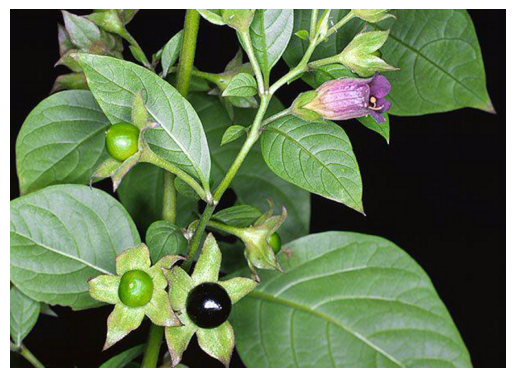

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
img = Image.open('results/restored_imgs/input.png')

# Visualizing the image in the notebook
plt.imshow(img)
plt.axis('off')  # Disabling the axis for a better visualization
plt.show()
